# Task 4: Location-based Analysis

## Objective
Perform a geographical analysis of restaurants using their location information and identify location-based insights.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load and Explore the Dataset

In [2]:
df = pd.read_csv("Dataset/Dataset.csv.csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.shape

(9551, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

## Step 3: Visualize Restaurant Locations

In [6]:
df[["Latitude", "Longitude"]].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


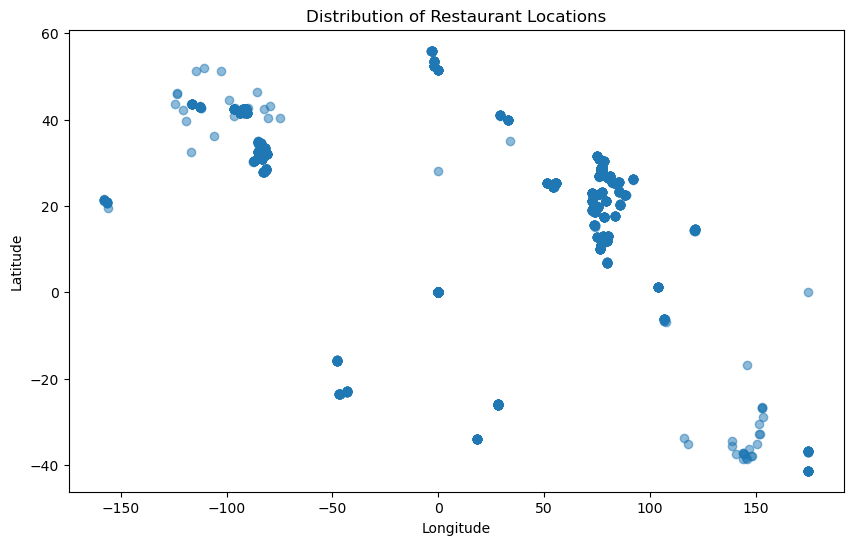

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.5
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribution of Restaurant Locations")
plt.show()

In [8]:
df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,9551.000000,9551.000000
mean,25.854381,64.126574
std,11.007935,41.467058
min,-41.330428,-157.948486
25%,28.478713,77.081343
50%,28.570469,77.191964
75%,28.642758,77.282006
max,55.976980,174.832089


## Step 4: Analyze Restaurant Concentration by City

In [19]:
city_counts = df["City"].value_counts()
city_counts

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64

In [10]:
city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

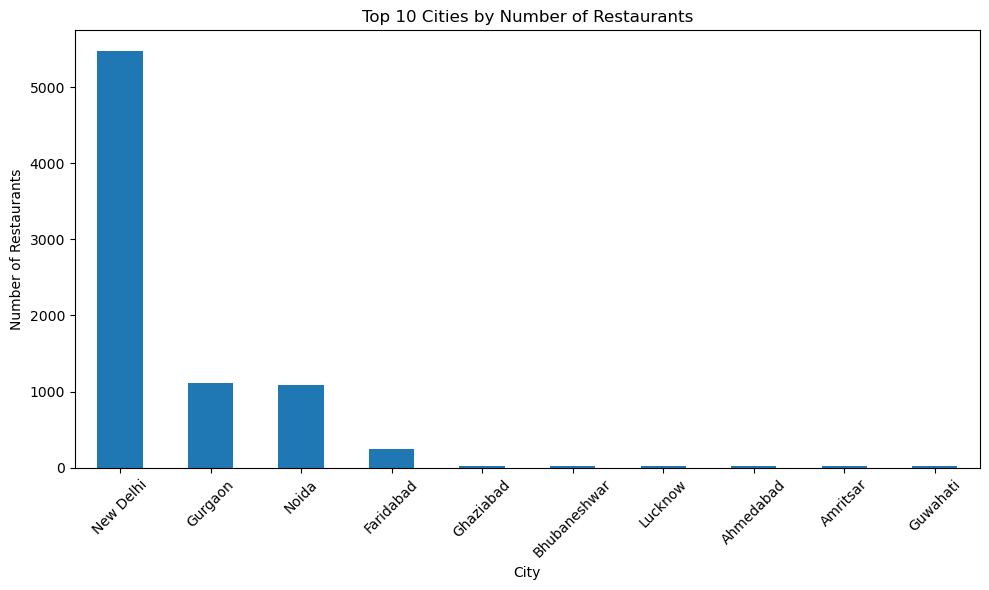

In [20]:
plt.figure(figsize=(10,6))
city_counts.head(10).plot(kind="bar")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
(city_counts.head(10) / len(df) * 100).round(2)

City
New Delhi       57.30
Gurgaon         11.71
Noida           11.31
Faridabad        2.63
Ghaziabad        0.26
Bhubaneshwar     0.22
Lucknow          0.22
Ahmedabad        0.22
Amritsar         0.22
Guwahati         0.22
Name: count, dtype: float64

## Step 5: Analyze Average Ratings by City

In [15]:
city_ratings = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
city_ratings

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64

In [14]:
city_ratings.head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

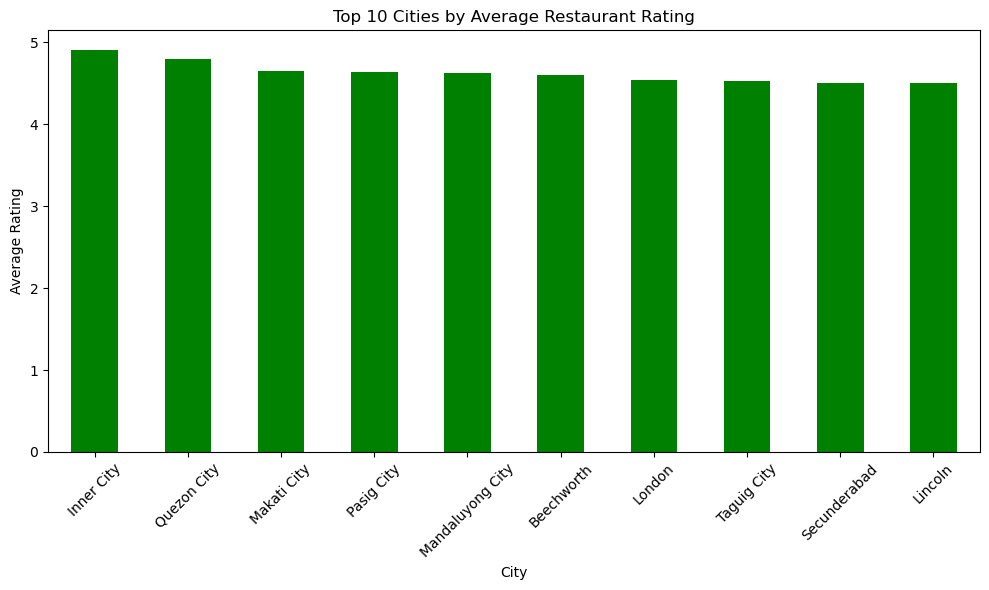

In [21]:
plt.figure(figsize=(10,6))
city_ratings.head(10).plot(kind="bar", color="green")
plt.title("Top 10 Cities by Average Restaurant Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
city_ratings.tail(10)

City
Consort        3.000000
Mayfield       2.900000
Ghaziabad      2.852000
Gurgaon        2.651431
Paynesville    2.600000
New Delhi      2.438845
Montville      2.400000
Mc Millan      2.400000
Noida          2.036204
Faridabad      1.866932
Name: Aggregate rating, dtype: float64

## Step 6: Analyze Average Price Range by City

In [22]:
city_price = df.groupby("City")["Price range"].mean().sort_values(ascending=False)
city_price

City
Panchkula           4.0
Vineland Station    4.0
Paynesville         4.0
Johannesburg        4.0
Inner City          4.0
                   ... 
Fernley             1.0
Dicky Beach         1.0
Miller              1.0
Mc Millan           1.0
Vernonia            1.0
Name: Price range, Length: 141, dtype: float64

In [23]:
city_price.head(10)

City
Panchkula           4.000000
Vineland Station    4.000000
Paynesville         4.000000
Johannesburg        4.000000
Inner City          4.000000
Pasay City          4.000000
Princeton           4.000000
Sandton             3.818182
Mandaluyong City    3.750000
Pretoria            3.700000
Name: Price range, dtype: float64

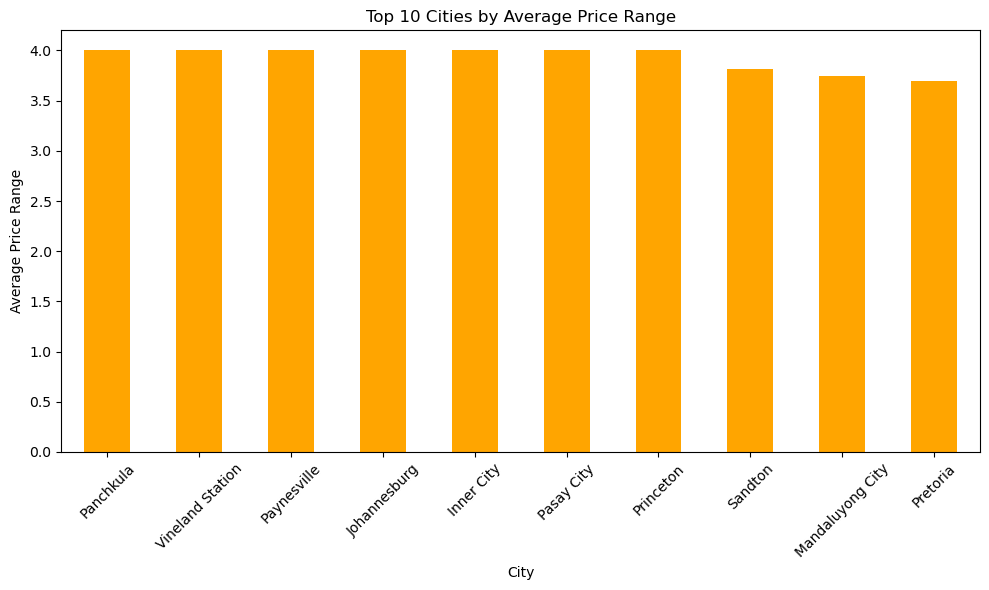

In [24]:
plt.figure(figsize=(10,6))
city_price.head(10).plot(kind="bar", color="orange")
plt.title("Top 10 Cities by Average Price Range")
plt.xlabel("City")
plt.ylabel("Average Price Range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
city_price.tail(10)

City
Dalton            1.4
Clatskanie        1.0
Lakes Entrance    1.0
Lakeview          1.0
Inverloch         1.0
Fernley           1.0
Dicky Beach       1.0
Miller            1.0
Mc Millan         1.0
Vernonia          1.0
Name: Price range, dtype: float64

## Step 7: Analyze Cuisine Distribution by City

In [33]:
city_cuisine = (
    df.dropna(subset=["Cuisines"])
      .groupby("City")["Cuisines"]
      .apply(lambda x: x.value_counts().idxmax())
)
city_cuisine

City
Abu Dhabi                                                   American
Agra                                           North Indian, Mughlai
Ahmedabad          Chinese, Italian, North Indian, Mexican, Medit...
Albany                                        Japanese, Steak, Sushi
Allahabad                                      North Indian, Chinese
                                         ...                        
Weirton                                      Burger, Greek, Sandwich
Wellington City                                                 Cafe
Winchester Bay                                Burger, Seafood, Steak
Yorkton                                                        Asian
��stanbul                                                       Cafe
Name: Cuisines, Length: 140, dtype: object

In [30]:
city_cuisine.head(10)

City
Abu Dhabi                                             American
Agra                                     North Indian, Mughlai
Ahmedabad    Chinese, Italian, North Indian, Mexican, Medit...
Albany                                  Japanese, Steak, Sushi
Allahabad                                North Indian, Chinese
Amritsar                                          North Indian
Ankara                                    Kebab, Turkish Pizza
Armidale                                       Bar Food, Steak
Athens                                American, Italian, Pizza
Auckland                                              Desserts
Name: Cuisines, dtype: object

In [31]:
df["City"].nunique()

141

## Step 8: Visualization

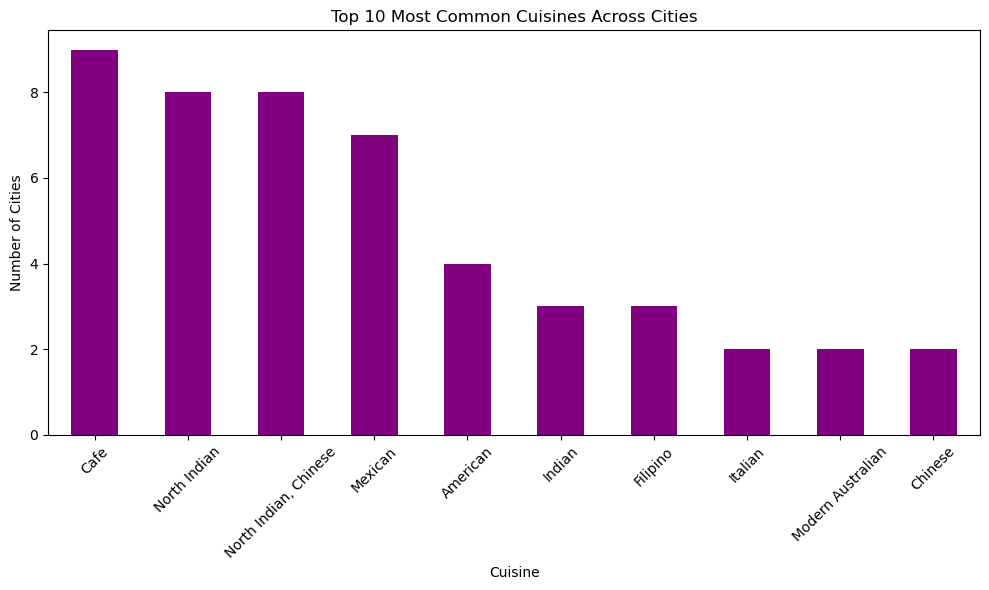

In [34]:
top_cuisines = city_cuisine.value_counts().head(10)
plt.figure(figsize=(10,6))
top_cuisines.plot(kind="bar", color="purple")
plt.title("Top 10 Most Common Cuisines Across Cities")
plt.xlabel("Cuisine")
plt.ylabel("Number of Cities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 9: Identify Interesting Insights

### Key Insights

- Restaurants are distributed across **141 cities**, showing a wide geographical coverage.
- **New Delhi** has the highest concentration of restaurants in the dataset.
- Restaurant ratings vary across cities, indicating differences in customer preferences and service quality.
- Average price ranges differ from city to city, reflecting variations in dining costs and customer spending patterns.
- The most common cuisine is different in different cities, highlighting regional food preferences.
- Geographical analysis helps identify restaurant hotspots and provides useful insights for business expansion and location-based decision making.

## Step 10: Final Results

In [32]:
print("Location-based Analysis Completed Successfully")
print("Total Restaurants:", len(df))
print("Total Cities:", df["City"].nunique())
print("City with Highest Number of Restaurants:", city_counts.idxmax())
print("Average Restaurant Rating:", round(df["Aggregate rating"].mean(), 2))
print("Average Price Range:", round(df["Price range"].mean(), 2))

Location-based Analysis Completed Successfully
Total Restaurants: 9551
Total Cities: 141
City with Highest Number of Restaurants: New Delhi
Average Restaurant Rating: 2.67
Average Price Range: 1.8


# Task 4 Summary

**Status:** Completed ✅

A comprehensive location-based analysis was performed using the geographical information available in the dataset. Restaurant locations were explored through latitude and longitude coordinates, and the distribution of restaurants across different cities was analyzed.

**Key Findings**
- Restaurants are distributed across **141 cities**, indicating wide geographical coverage.
- **New Delhi** has the highest concentration of restaurants in the dataset.
- Average restaurant rating across the dataset is **2.67**.
- The average price range is **1.80**, indicating that most restaurants fall within the lower to mid-price categories.
- Cuisine preferences vary across cities, highlighting regional food diversity and dining trends.

**Conclusion:** The location-based analysis successfully identified restaurant distribution patterns, city-wise statistics, and geographical insights. These findings can help understand restaurant concentration, customer preferences, and regional dining characteristics.